# Using the Pharaglow-Analysis toolset for data analysis

Pharaglow- Analysis is a multi-purpose timeseries analysis tool. It is designed to work with time tracking data of the form (time, x, y) and can also accommodate centerline data.

Originally, its designed to work with outputs from PharaGlow, but it can flexibly load other types of tracking data.

In [1001]:
import numpy as np
import importlib
from pathlib import Path
import pandas as pd
import warnings
import matplotlib.pylab as plt


import pg_analysis.plotter as pga
import pg_analysis.loader as loader


importlib.reload(pg_analysis.plotter)
importlib.reload(pg_analysis.loader)

<module 'pg_analysis.loader' from '/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/loader.py'>

## Loading data

Data loading is essential: Here is where we have some standards to unify downstream analyses. Key are:
- usage of units to propagate when we calculate new derived columns of data
- scaling of time and space, using units. Here, we expect that scale has appropriate world units to convert from e.g. pixel to um and fps allows us to go from frames to time frames/fps = time



### Loading pharaglow data
 to add

### Loading analyzed macroscope data

This pre-built loader loads files after https://github.com/scholz-lab/MacroscopeDataAnalysis has run. Note, that the resulting columns already have units (x,y um). The scale should therefore be set to 1. The loader will automatically find files in the path matching patterns of 'filterword'. It will also find corresponding centerline .csv if present.

In [1002]:
ls 'data/macroscope_analyzed/'

MKSO0016_figure.pdf          MKSO0023_signals.json
MKSO0016_px_centerlines.csv  MKSO0023_um_centerlines.csv
MKSO0016_signals.json        MKSO0024_figure.pdf
MKSO0016_um_centerlines.csv  MKSO0024_px_centerlines.csv
MKSO0018_figure.pdf          MKSO0024_signals.json
MKSO0018_px_centerlines.csv  MKSO0024_um_centerlines.csv
MKSO0018_signals.json        MKSO0025_figure.pdf
MKSO0018_um_centerlines.csv  MKSO0025_px_centerlines.csv
MKSO0019_figure.pdf          MKSO0025_signals.json
MKSO0019_px_centerlines.csv  MKSO0025_um_centerlines.csv
MKSO0019_signals.json        MKSO0026_figure.pdf
MKSO0019_um_centerlines.csv  MKSO0026_px_centerlines.csv
MKSO0020_figure.pdf          MKSO0026_signals.json
MKSO0020_px_centerlines.csv  MKSO0026_um_centerlines.csv
MKSO0020_signals.json        MKSO0027_figure.pdf
MKSO0020_um_centerlines.csv  MKSO0027_px_centerlines.csv
MKSO0021_figure.pdf          MKSO0027_signals.json
MKSO0021_px_centerlines.csv  MKSO0027_um_centerlines.csv
MKSO0021_signals.json        MKSO002

In [1003]:
macroscope_data_path = 'data/macroscope_analyzed/'

# which columns to load, if None, load all
cols = ['frame', 'x', 'y', 'skew']

# define which loader to use or build your own
loader_class = loader.MacroscopeLoader

In [1004]:
# generate a container object
macroscope_data = pga.Experiment(strain='INF189', condition='ATR-', scale=1, fps=30., loader_cls = loader_class, loader_kwargs={'strict_columns': False, 'strict_units':True})
# filter only a few of the files using *glob syntax
dsets = [f'MKSO00{i:02}' for i in [16,18,19, 20, 21, 22, 23, 24]]
for movie in dsets:
    macroscope_data.load_data(macroscope_data_path, 
            columns=cols, filterword = f"{movie}_signals.json"
            )

Reading data/macroscope_analyzed/MKSO0016_signals.json


/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/plotter.py:990: UserWarning: Particle index could not be extracted. Using consecutive numbers.
  warnings.warn('Particle index could not be extracted. Using consecutive numbers.')


Reading data/macroscope_analyzed/MKSO0018_signals.json


/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/plotter.py:990: UserWarning: Particle index could not be extracted. Using consecutive numbers.
  warnings.warn('Particle index could not be extracted. Using consecutive numbers.')


Reading data/macroscope_analyzed/MKSO0019_signals.json
Reading data/macroscope_analyzed/MKSO0020_signals.json
Reading data/macroscope_analyzed/MKSO0021_signals.json
Reading data/macroscope_analyzed/MKSO0022_signals.json
Reading data/macroscope_analyzed/MKSO0023_signals.json
Reading data/macroscope_analyzed/MKSO0024_signals.json


In [1005]:
macroscope_data.units

{'space_units': 'um',
 'time_units': 's',
 'frame': 1,
 'x': 'um',
 'y': 'um',
 'skew': 'a.f.u'}

### Loading raw macroscope data (stage files)

Here, we load the raw files generated by GlowTracker https://github.com/scholz-lab/GlowTracker. This is also a pre-built loader.
Note that the GlowTracker default is to save stage coordinates in mm. Either you update the units to 'x', 'y' in 'mm' or set the scale to 1000 to obtain the correct values for real-world measurements of e.g. speed.

In [1006]:
macroscope_raw_data_path = 'data/macroscope_raw/'

# which columns to load, if None, load all
cols = ['frame', 'x', 'y', 'skew']

# define which loader to use or build your own
loader_class_raw = loader.MacroscopeRawStageLoader

In [1007]:
# Create experiment and load data
stage_data = pga.Experiment(strain='INF189', condition='ATR-', scale=1, fps=30., loader_cls = loader_class_raw, loader_kwargs={'strict_columns': False, 'strict_units':True})
stage_data.load_data(macroscope_raw_data_path, 
                  columns=cols, 
                  filterword='*-coords*', extension='.txt')

Reading data/macroscope_raw/MKSO0011_2026-02-11-14-39-22-810043-coords.txt
Reading data/macroscope_raw/MKSO0014_2026-02-11-14-45-08-765761-coords.txt
Reading data/macroscope_raw/MKSO0002_2026-02-11-12-40-05-593252-coords.txt
Reading data/macroscope_raw/MKSO0008_2026-02-11-14-00-26-813578-coords.txt
Reading data/macroscope_raw/MKSO0001_2026-02-11-12-38-14-998590-coords.txt
Reading data/macroscope_raw/MKSO0004_2026-02-11-12-45-07-334698-coords.txt
Reading data/macroscope_raw/MKSO0006_2026-02-11-13-48-19-927742-coords.txt
Reading data/macroscope_raw/MKSO0007_2026-02-11-13-54-37-162381-coords.txt
Reading data/macroscope_raw/MKSO0009_2026-02-11-14-09-29-712933-coords.txt
Reading data/macroscope_raw/MKSO0003_2026-02-11-12-43-00-973304-coords.txt
Reading data/macroscope_raw/MKSO0005_2026-02-11-13-52-08-855156-coords.txt
Reading data/macroscope_raw/MKSO0010_2026-02-11-14-11-14-516036-coords.txt
Reading data/macroscope_raw/MKSO0013_2026-02-11-14-43-13-753456-coords.txt
Reading data/macroscope_r

/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/plotter.py:990: UserWarning: Particle index could not be extracted. Using consecutive numbers.
  warnings.warn('Particle index could not be extracted. Using consecutive numbers.')


We handle units in the loader or the user supplies a units dictionary. For fun, we will pretend the units are km!

In [1008]:
print('Automatically detected units:', stage_data.units)
# the append keyword allows to add more data or - if false - resets the samples in the experiment to []
false_units = {'x': 'km', 'y': 'km'}
stage_data.loader_kwargs = {'strict_columns': False, 'strict_units':True, 'units': false_units}
stage_data.load_data(macroscope_raw_data_path, 
                  columns=cols, 
                  filterword='*-coords*', extension='.txt', append = False)
print('Funny manual units:', stage_data.units)
# lets redo and synchronize the units - if we correct the first sample, synchromize will do the rest
stage_data.samples[0].units = loader_class_raw.UNITS
stage_data.synchronize_units()
print('Corrected units:', stage_data.units)

Automatically detected units: {'space_units': 'um', 'time_units': 's', 'frame': 1, 'x': 'mm', 'y': 'mm'}
Reading data/macroscope_raw/MKSO0011_2026-02-11-14-39-22-810043-coords.txt
Reading data/macroscope_raw/MKSO0014_2026-02-11-14-45-08-765761-coords.txt
Reading data/macroscope_raw/MKSO0002_2026-02-11-12-40-05-593252-coords.txt
Reading data/macroscope_raw/MKSO0008_2026-02-11-14-00-26-813578-coords.txt
Reading data/macroscope_raw/MKSO0001_2026-02-11-12-38-14-998590-coords.txt
Reading data/macroscope_raw/MKSO0004_2026-02-11-12-45-07-334698-coords.txt
Reading data/macroscope_raw/MKSO0006_2026-02-11-13-48-19-927742-coords.txt
Reading data/macroscope_raw/MKSO0007_2026-02-11-13-54-37-162381-coords.txt
Reading data/macroscope_raw/MKSO0009_2026-02-11-14-09-29-712933-coords.txt
Reading data/macroscope_raw/MKSO0003_2026-02-11-12-43-00-973304-coords.txt
Reading data/macroscope_raw/MKSO0005_2026-02-11-13-52-08-855156-coords.txt
Reading data/macroscope_raw/MKSO0010_2026-02-11-14-11-14-516036-coords

/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/plotter.py:990: UserWarning: Particle index could not be extracted. Using consecutive numbers.
  warnings.warn('Particle index could not be extracted. Using consecutive numbers.')


### Load from pickle files

We can pickle objects and load them. Especially useful if large amounts of files were loaded as intermediate storage.

In [1009]:
# save as Experiment as pickle
stage_data.dump('data/StageData_pickle')

# ... or load from a previously pickled Experiment object.

stage_data = pga.Experiment.load('data/StageData_pickle')
stage_data

Experiment 
 Strain: INF189,
 Condition: ATR-
 N = 16.

### Add metadata

In [1010]:
# experimental metdadata
info = {"strain":macroscope_data.strain, "experimenter":"MKS", "OFF FOOD":"NO", 'stage':'adults'}
macroscope_data.define_metadata(info)

In [1011]:
macroscope_data.experiment_metadata

{'strain': 'INF189',
 'experimenter': 'MKS',
 'OFF FOOD': 'NO',
 'stage': 'adults'}

### Saving and exporting data

In [1012]:
# ... we can also dump a pickle object to save the current state of the Experiment variable.
# macroscope_data.dump('data/Test_2')

# or export it into the wcon format https://github.com/openworm/tracker-commons/blob/master/WCON_format.md

macroscope_data.save_wcon(filepath = 'data/test.wcon', tag = '@INF')


We will proceed with a specific dataset for simplicity!

In [1013]:
control = macroscope_data
control

Experiment 
 Strain: INF189,
 Condition: ATR-
 N = 8.

### Filter data

In [1014]:
print(f'Sample remaining: {len(control)}')

# we check if conditions are fullfilled for each sample and retain only suitable ones. Here - we filter by duration of the tracks
tmp = []
for worm in control.samples:
    if len(worm.data)>worm.fps*30:
        tmp.append(worm)
control.samples = tmp

print(f'Sample remaining: {len(control)}')

Sample remaining: 8
Sample remaining: 8


### 2. Eploring the Experiment object
An Experiment object is a container for the Worm object. Each worm object contains the phargalow data table. You can print either the Experiment or a single worm to get a description.

In [1015]:
#the class supports slicing
# get just a few samples. a is still an Experiment object
a = control[0:2]
print(a)

Experiment 
 Strain: INF189,
 Condition: ATR-
 N = 2.


In [1016]:
# it also allows addition if you loaded two objects for example.
a = control[0]+control[1]
a

Experiment 
 Strain: INF189,
 Condition: ATR-
 N = 2.

In [1017]:
# if you want to access the underlying worm class, use get_sample(n) 
w = control.get_sample(0)
w

Worm 
 with underlying data:             frame             x              y         skew         time  \
count  2500.00000   2500.000000    2500.000000  2500.000000  2500.000000   
mean   1249.50000  91315.511276   99694.220014     7.592881    41.650000   
std     721.83216    454.866012     271.501179     0.362759    24.061072   
min       0.00000  90678.911586   99283.883447     5.507385     0.000000   
25%     624.75000  90862.629838   99416.458509     7.386607    20.825000   
50%    1249.50000  91323.376920   99708.754028     7.598748    41.650000   
75%    1874.25000  91620.350610   99935.911667     7.857866    62.475000   
max    2499.00000  92328.080870  100184.863089     8.363045    83.300000   

           x_scaled       y_scaled  
count   2500.000000    2500.000000  
mean   91315.511276   99694.220014  
std      454.866012     271.501179  
min    90678.911586   99283.883447  
25%    90862.629838   99416.458509  
50%    91323.376920   99708.754028  
75%    91620.350610   99935

### 3. Calculating additional columns


We can calculate a velocity and pumping rates. But we can also get reversals, a windowed pumping count or recalculate the pumping rate with new peak-finding parameters.

In [1018]:
# print available functions
control[:1].calculate_property('help')

dict_keys(['velocity', 'time', 'preprocess_signal', 'locations', 'reversals', 'count_rate', 'smoothed', 'pumps', 'nose_speed', 'reversals_nose'])


#### Getting some very basic calculations going

In [1019]:
for experiment in [control]: # this is useful if you are doing this for two expeirments e.g. control and mutant
    experiment.calculate_property('time')
    experiment.calculate_property('locations')
    experiment.calculate_property('velocity', dt = 15)
    experiment.calculate_property('smoothed', key = 'velocity', window= 90, center = False)

#### Extracting peaks from a column

In [1020]:
# add negskew - this is a specific way to get pumps out of pharaglow-type data. We will useit to demonstrate adding new columns and detecting peaks. 
for experiment in [control]:
    for w in experiment.samples:
        w.add_column('negskew', -1*w.data['skew'], unit=1)
    experiment.calculate_property('preprocess_signal', key='negskew', w_outlier=None, w_bg=30, w_smooth=1)
    experiment.calculate_property("pumps", key='negskew_clean', **ppars)
    # countrate
    experiment.calculate_property("count_rate", key='pump_events', window=90, min_periods=90)
    experiment.calculate_property("smoothed", key='count_rate_pump_events', window=90, min_periods=90)

    

/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/tools.py:67: PeakPropertyWarning: some peaks have a prominence of 0
  prom,_,_  = peak_prominences(signal, peaks, wlen)
/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/tools.py:67: PeakPropertyWarning: some peaks have a prominence of 0
  prom,_,_  = peak_prominences(signal, peaks, wlen)
/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/tools.py:67: PeakPropertyWarning: some peaks have a prominence of 0
  prom,_,_  = peak_prominences(signal, peaks, wlen)
/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/tools.py:67: PeakPropertyWarning: some peaks have a prominence of 0
  prom,_,_  = peak_prominences(signal, peaks, wlen)
/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/tools.py:67: PeakProperty

#### And calculating reversals
(a) using Hardaker et al. based on cms tracks and
(b) requires centerlines

In [1021]:
for experiment in [control]:
    experiment.calculate_property('reversals', animal_size=50, angle_threshold = 120)
    experiment.calculate_property('reversals_nose', dt = 10, angle_threshold=140, w_smooth = 15, min_duration = 10)
    # add signed velocity
    for w in experiment.samples:
        w.add_column('signed_velocity', np.sign(1-2*w.data['reversals_nose'])*w.data['velocity_smoothed'], unit='um/s')

### 4. Aligning data temporally

In [1022]:
# to align all worms in an experiment to a global timepoint -- e.g. a global stimulus
control.align_data(timepoints = [100], tau_before = 300, tau_after = 300, key = None)

# # or align each worm to its own timepoints - here we use the reversals
for worm in control.samples:
    events = worm.get_events('reversals')
    worm.multi_align(events, tau_before=300, tau_after=600, key = None)


Plot shows sample-None for y over sample-None for x.


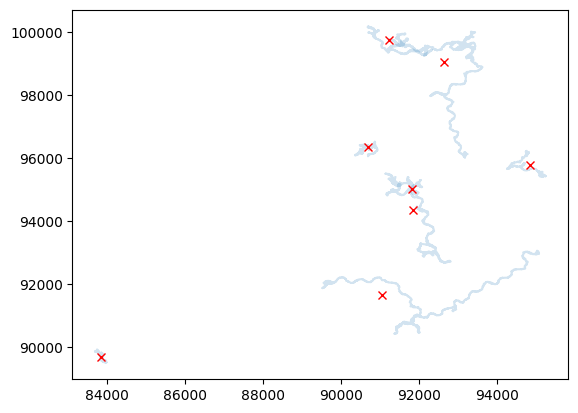

In [1023]:
control.plot(plt.gca(), ('x', 'y'), metric = None, plot_type = 'line', color = 'C0', alpha = 0.2)
[plt.plot(w.get_aligned_metric('x', 'mean').loc[0], w.get_aligned_metric('y', 'mean').loc[0], 'rx') for w in control.samples];

### 5. Getting data out

mean 92.56336624660052
sem 1.4611074425504074
std 72.83587627200167
N 2485


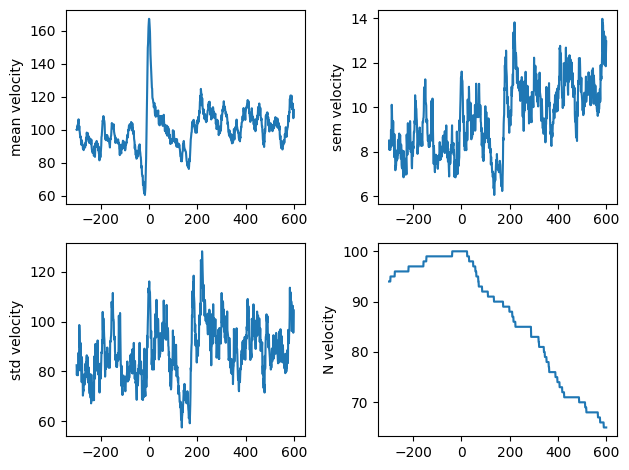

In [1024]:
######################################
#
#    calculate metrics at the worm level or experiment level
#
#######################################
# # metric at the worm level, eg. average velocity
w = control.get_sample(0)
for m in ['mean', 'sem', 'std', 'N']:
    t = w.get_metric('velocity', m)
    print(m, t)


# # metric at the experiment level.
plt.figure()
key = 'velocity'
for i, metric in enumerate(['mean', 'sem', 'std', 'N']):
    plt.subplot(2,2,i+1)
    t = control.get_aligned_sample_metric(key, metric)
    plt.plot(t, color = 'C0', alpha = 0.1)
    plt.ylabel(f"{metric} {key}")
    
key = 'velocity'
for i, metric in enumerate(['mean', 'sem', 'std', 'N']):
    plt.subplot(2,2,i+1)
    t = control.get_aligned_sample_metric(key, metric)
    plt.plot(t, color = 'C0', alpha = 1)
    plt.ylabel(f"{metric} {key}")
plt.tight_layout()

### 5. Plotting utilities

There are built-in plots for quick visulaizations in the package. These are basic and meant to provide quick overviews. 
There are 6 basic plot types illustrated below. 

- 'metric': defines the reducing function across samples (worms)
- 'axis': defines the reducing function across time (axis = 0) or across samples (axis=1)
- 'plot_type': specify the type of visual 
- 'metric_error': define how an error bar is calculated. Only used for certain plot types.


- all plots take additional matplotlib keyword arguments
- to use a previously aligned dataset, use aligned = True

Plot shows sample-mean for velocity over sample-mean for time. Using aligned data.
Plot shows time-mean for velocity over time-mean for time.
Plot shows time-mean for velocity over time-mean for rate.
Plot shows time-mean for velocity over time-mean for time.
Plot shows sample-collapse for velocity over sample-collapse for time.


/gpfs/soma_fs/home/scholz/Data/202602_Optogenetics_analyzed/figures/Pharaglow-Analysis/pg_analysis/plotter.py:95: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  num_bins = kwargs.pop('nbins', int(y.count()**0.5))


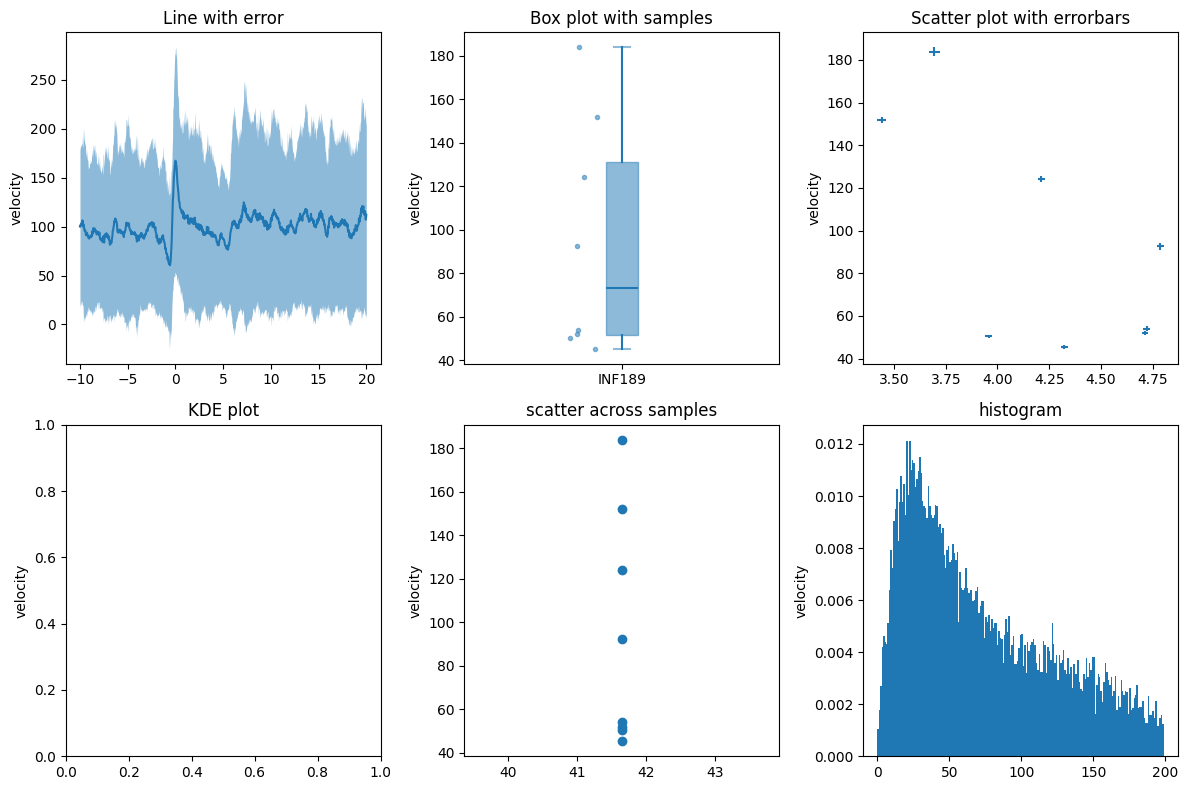

In [1025]:
# basic plot types
fig, ((ax1, ax2, ax3), ( ax4, ax5, ax6)) = plt.subplots(nrows=2, ncols=3, figsize = (12, 8))
key_x = 'time'
key_y = 'velocity'

plot, x, y = control.plot(ax1, (key_x, key_y), metric = 'mean', plot_type = 'line', metric_error = 'std', aligned = True, axis=1)
plot, x, y = control.plot(ax2, (key_x, key_y),metric = 'mean', plot_type = 'box', loc = 0,axis=0)
plot, x, y = control.plot(ax3, ('rate', key_y), metric = 'mean', plot_type = 'xy_error_scatter', metric_error = 'sem', marker=None, axis=0)
#plot, x, y = control.plot(ax4, ('x', key_y), metric = None, plot_type = 'density', metric_error = None, axis=0)
plot, x, y = control.plot(ax5, (key_x, key_y), metric = 'mean',  plot_type = 'scatter', axis = 0)
plot, x, y = control.plot(ax6, key_y, metric = 'collapse',  plot_type = 'histogram', nbins =range(0,200))

for ax, txt in zip(fig.axes, ['Line with error', 'Box plot with samples', 'Scatter plot with errorbars', 'KDE plot', 'scatter across samples', 'histogram']):
    ax.set_title(txt)
    ax.set_ylabel(key_y)
plt.tight_layout()

In [1026]:
plot, x, y = control.plot(ax4, ('rate', key_y), metric = 'mean', plot_type = 'scatter', metric_error = None, axis=1)

Plot shows sample-mean for velocity over sample-mean for rate.


In [1027]:
np.isfinite(y)

frame
0        True
1        True
2        True
3        True
4        True
        ...  
2495    False
2496    False
2497    False
2498    False
2499    False
Length: 2500, dtype: bool

#### Box plots - summary stats

Very useful to compare datasets. All plot utilities return the underlying dataframes (e.g., here x1, y1), which can be used to calculate statistics.

Plot shows time-mean for velocity over time-mean for time.
Plot shows time-mean for velocity over time-mean for time.


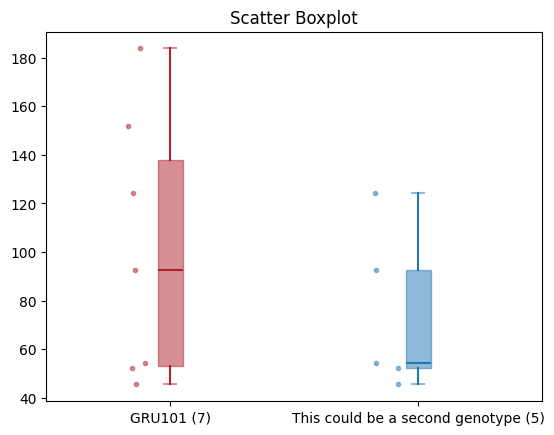

In [1028]:
# box plots!
plt.figure()
ax = plt.subplot(111)
ax.set_title('Scatter Boxplot')
# you can filter results by row = here it would be applied before averaging such that individual worms are removed.
control.set_color(style.R1)
plot1, x1, y1 = control.plot(ax, 'velocity',metric = 'mean',  plot_type = 'box', loc = 0, filterfunction = lambda x: np.any(x>300), axis=0)
N1 = len(y)
# slicing makes a copy! Note how the object doesn't have the same color
plot2, x2, y2 = control[0:5].plot(ax, 'velocity',metric = 'mean', plot_type = 'box', loc = 1, filterfunction = lambda x: np.any(x>0), axis=0)
# need to add our labels back when doing two plots
ax.set_xticks([0,1])
ax.set_xticklabels([f'GRU101 ({len(y1)})', f'This could be a second genotype ({len(y2)})'])
plt.show()

#### 2D - density and lineplots

Plot shows sample-None for y over sample-None for x.
Plot shows sample-mean for y over sample-mean for x.


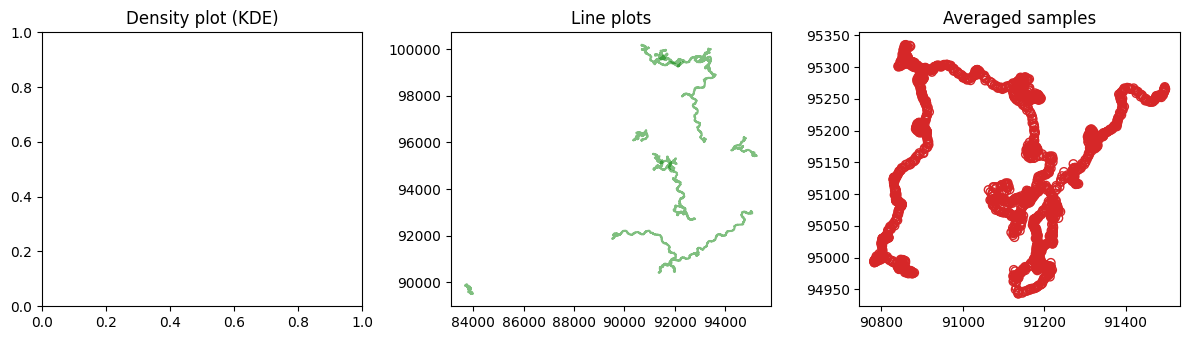

In [1029]:
plt.figure(figsize = (12,3.5))
ax = plt.subplot(131)
ax.set_title('Density plot (KDE)')
#plot, x, y = control.plot(ax, ('x', 'y'), metric = None, axis=0, plot_type = 'density', metric_error = None)
ax = plt.subplot(132)
ax.set_title('Line plots')
control.plot(ax, ('x', 'y'), metric = None,  alpha = 0.5, color = 'green')
ax = plt.subplot(133)
ax.set_title('Averaged samples')
control.plot(ax, ('x', 'y'), metric = 'mean', plot_type = 'scatter', marker = 'o',facecolor='none',edgecolor='C3')
plt.tight_layout()

In [1030]:
y

frame
0       74.273297
1       70.146389
2       66.626324
3       70.745095
4       71.719894
          ...    
2495          NaN
2496          NaN
2497          NaN
2498          NaN
2499          NaN
Length: 2500, dtype: float64

#### Scatter in multiple plots

Plot shows sample-None for rate over sample-None for velocity.


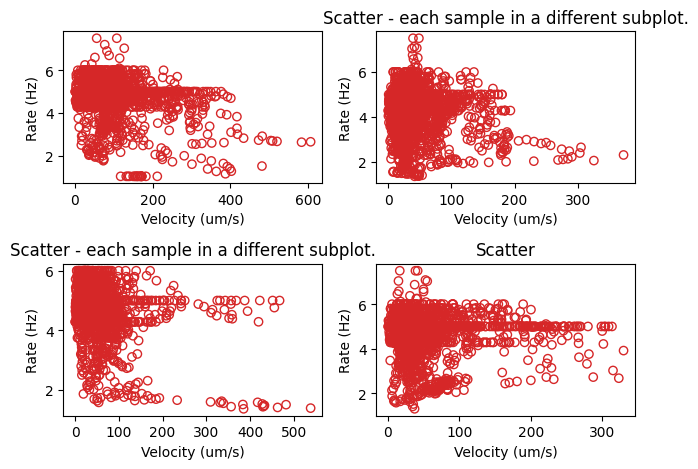

In [1031]:
# scatter two variables against each other with different subplot options
plt.figure()
ax0 = plt.subplot(221)
ax1 = plt.subplot(222)
ax2 = plt.subplot(223)
ax3 = plt.subplot(224)
axes = [ax0, ax1, ax2, ax3]
for ax in axes:
    ax.set_ylabel('Rate (Hz)')
    ax.set_xlabel('Velocity (um/s)')
ax.set_title('Scatter')
control[:4].plot(axes, ('velocity', 'rate'), metric = None, axis=1, plot_type='scatter', fc ='none', ec = 'C3')
ax1.set_title('Scatter - each sample in a different subplot.')
ax2.set_title('Scatter - each sample in a different subplot.')

plt.tight_layout()

#### Timeseries

Plot shows sample-mean for velocity over sample-mean for time. Using aligned data.
Plot shows sample-None for velocity over sample-None for time. Using aligned data.


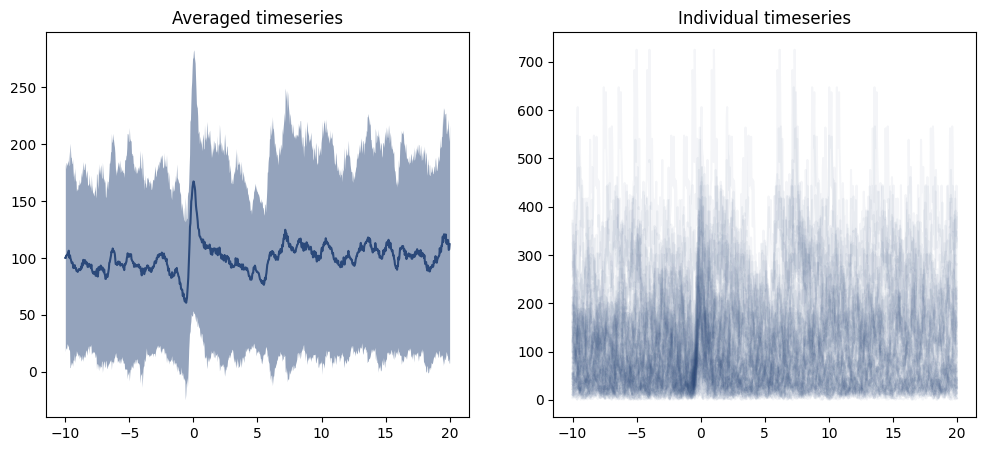

In [1032]:
plt.figure(figsize = (12, 5))
control.set_color(style.B1)
ax1 = plt.subplot(121)
ax1.set_title('Averaged timeseries')
control.plot(ax1, 'velocity',  metric = 'mean', metric_error = 'std', aligned = True);
ax2 = plt.subplot(122)
ax2.set_title('Individual timeseries')
control.plot(ax2, 'velocity', metric = None, alpha = 0.05, aligned = True);

#### Event plots

Plot shows sample-None for negskew over sample-None for time_aligned. Using aligned data.


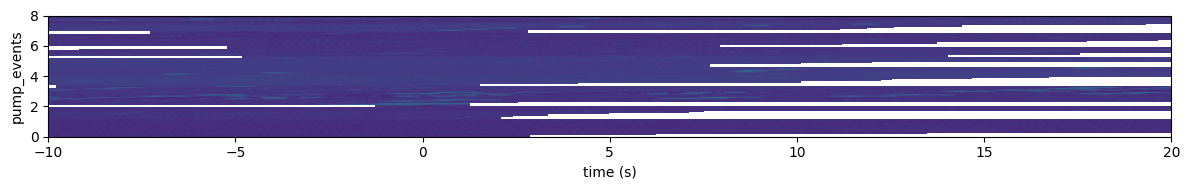

In [1033]:
fig, axes = plt.subplots(1,1, figsize=(12,2))

plot, x, y = control.plot(axes, ('time_aligned','negskew'), metric = None, plot_type = 'raster', 
                                  aspect ='auto', vmin=-10, vmax = 5, aligned = True, cmap = 'viridis')#,filterfunction = lambda x:~np.any(np.isnan(x)))
# correct x-axis - use aligned time
plot[0].set_extent([x.mean(axis=1).min(),x.mean(axis=1).max(),0,len(control)])
#axes.set_aspect(len(x)//len(y))
plt.setp(axes, ylabel='pump_events', xlabel = 'time (s)')
plt.tight_layout()

Plot shows sample-None for reversals over sample-None for time_aligned. Using aligned data.


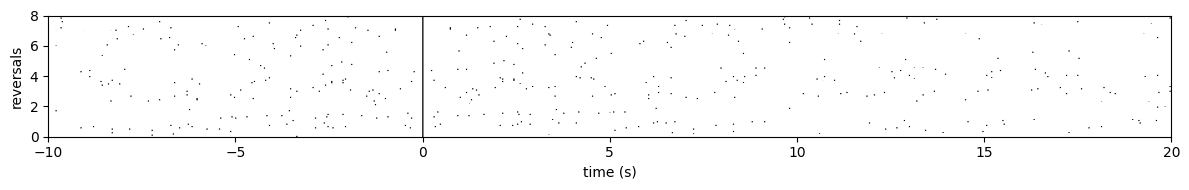

In [1034]:
fig, axes = plt.subplots(1,1, figsize=(12,2))

plot, x, y = control.plot(axes, ('time_aligned','reversals'), metric = None, plot_type = 'raster', 
                                  aspect ='auto', vmin=0, vmax = 1, aligned = True, cmap = 'gray_r')#,filterfunction = lambda x:~np.any(np.isnan(x)))
# correct x-axis - use aligned time
plot[0].set_extent([x.mean(axis=1).min(),x.mean(axis=1).max(),0,len(control)])
#axes.set_aspect(len(x)//len(y))
plt.setp(axes, ylabel='reversals', xlabel = 'time (s)')
plt.tight_layout()

Plot shows sample-mean for velocity_smoothed over sample-mean for time. Using aligned data.
Plot shows sample-None for y over sample-None for x.


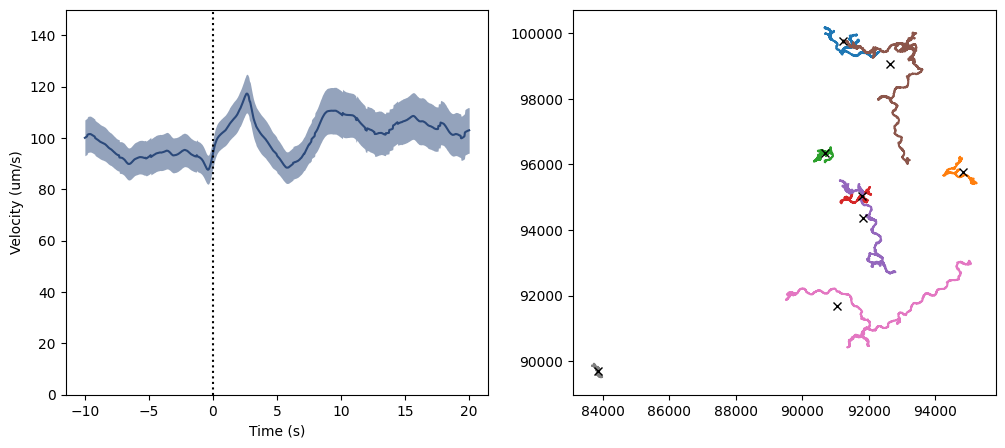

In [1035]:
plt.figure(figsize = (12, 5))
control.set_color(style.B1)
ax1 = plt.subplot(121)
control.plot(ax1, 'velocity_smoothed',  metric =  'mean', metric_error = 'sem', aligned = True, alpha_error = 0.5);
plt.ylabel('Velocity (um/s)')
plt.xlabel('Time (s)')
plt.axvline(0, color = 'k', linestyle=':')
plt.ylim(0,150)
ax2 = plt.subplot(122)

control.plot(plt.gca(), ('x', 'y'), metric = None, plot_type = 'line', color = None)
[plt.plot(w.get_aligned_metric('x', 'mean').loc[0], w.get_aligned_metric('y', 'mean').loc[0], 'kx') for w in control.samples];
#plt.savefig('Lawnentry.svg')

#### Categorical plots (experimental)

In [1042]:
# show comparative plots between groups in a categorical 
categorical_velocity = control.get_sample_metric_categorical(key = 'velocity', category='reversals', metric='mean')
categorical_velocity

,velocity,velocity,velocity,velocity,velocity,velocity,velocity,velocity
reversals,,,,,,,,
0,91.949752,45.188873,51.742169,54.065625,123.713252,183.473743,151.562339,50.053443
1,200.866243,91.374179,134.738592,62.902388,191.781480,238.194817,245.647241,110.586243


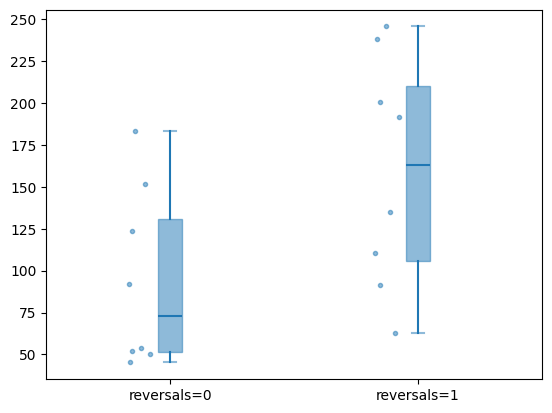

In [1044]:
plot,x,y = control.categorical_plot(plt.gca(), key = 'velocity', category = 'reversals', metric = 'mean')